# Análisis Exploratorio de Indicadores de Suelo y Sociales

Análisis exploratorio del dataset `INDICADORES_ESTUDIO_GRAL.csv` que integra variables de uso del suelo e indicadores socioeconómicos a nivel municipal. El notebook carga, limpia y valida los datos, para luego examinar su estructura estadística y visualizar relaciones entre los indicadores de suelo (WEI, TCMA, población urbana, densidad) e indicadores sociales (pobreza, GINI, informalidad, vivienda, corrupción, percepción verde, contaminación) por subregión.

## 1. Carga y preparación de datos

- Carga del dataset y renombramiento de columnas a nombres descriptivos
- Limpieza de tipos numéricos con manejo de nulos y totales residuales

In [20]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == 'src' else cwd
DATA_DIR = root / 'data'
DOC_DIR = root / 'doc'
EXPORT_DIR = DATA_DIR / 'export'


In [21]:
df = pd.read_csv(DATA_DIR / 'INDICADORES_ESTUDIO_GRAL_V1.csv')

rename_map = {
    'IND 1.1': 'WEI',
    'IND 1.2': 'TCMA_URBANO',
    'IND 1.3': 'Porc_poblacion_en_urbana',
    'IND 1.4': 'Densidad_urbana',
    'IND 2.1': 'Ind_POT',
    'IND 2.2': 'Ind_eficiencia_recaudo',
    'IND 2.3': 'Ingresos_tributarios_percap',
    'IND 2.4': 'Percepcion_corrupcion',
    'IND 2.5': 'Percepcion_verde',
    'IND 3.1': 'Porc_pobreza_monetaria',
    'IND 3.2': 'Porc_pobreza_extrema',
    'IND 3.3': 'Porc_pobreza_multi',
    'IND 3.4': 'GINI',
    'IND 3.5': 'Porc_informal',
    'IND 4.1': 'Porc_deficit_vivienda_cuali',
    'IND 4.2': 'Porc_deficit_vivienda_cuanti',
    'IND 4.3': 'Porc_contaminacion_aire',
    'IND 4.4': 'Porc_contaminacion_agua',
}
df = df.rename(columns=rename_map)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
df.head(25).to_string()

Shape: (25, 33)
Columns: ['SUBREGIÓN', 'MUNICIPIO', 'AREA KM2', 'AREA KM2 URBANA', 'POBLACION ESTIMADA 2021/RURAL', 'POBLACION ESTIMADA 2021/URBANA', 'TOTAL POBLACIÓN', 'WEI', 'TCMA_URBANO', 'Porc_poblacion_en_urbana', 'Densidad_urbana', 'IND 2.1 TIPO', 'Ind_POT', 'AÑOS REVISION', 'AÑO ULTIMA REVISION', 'IND 2.1 REVISION', 'IND 2.1 ZONAS AMB', 'Ind_eficiencia_recaudo', 'Ingresos_tributarios_percap', 'Percepcion_corrupcion', 'Percepcion_verde', 'Porc_pobreza_monetaria', 'Porc_pobreza_extrema', 'Porc_pobreza_multi', 'GINI', 'Porc_informal', 'Porc_deficit_vivienda_cuali', 'Porc_deficit_vivienda_cuanti', 'Porc_contaminacion_aire', 'Porc_contaminacion_agua', 'CAGR_AGRICULTURA', 'CAGR_BOSQUE', 'CAGR_AGUA']



'              SUBREGIÓN     MUNICIPIO     AREA KM2 AREA KM2 URBANA  POBLACION ESTIMADA 2021/RURAL  POBLACION ESTIMADA 2021/URBANA  TOTAL POBLACIÓN     WEI TCMA_URBANO Porc_poblacion_en_urbana Densidad_urbana IND 2.1 TIPO Ind_POT AÑOS REVISION  AÑO ULTIMA REVISION  IND 2.1 REVISION IND 2.1 ZONAS AMB Ind_eficiencia_recaudo Ingresos_tributarios_percap Percepcion_corrupcion Percepcion_verde Porc_pobreza_monetaria Porc_pobreza_extrema Porc_pobreza_multi    GINI Porc_informal Porc_deficit_vivienda_cuali Porc_deficit_vivienda_cuanti Porc_contaminacion_aire Porc_contaminacion_agua CAGR_AGRICULTURA CAGR_BOSQUE CAGR_AGUA\n0   Sabana noroccidente      El Rosal     87,12009           5,403                         2494.0                         22051.0          24545.0  0,1494      1,7158                   88,40%     4081,251157          EOT    0,75         -6,00               2015.0               1.0              0,50            62,04/47,12                     367.868                33,24%       

In [22]:
print(df.dtypes)
print()
print('Rows:', len(df))
print('SUBREGIÓN values:', df['SUBREGIÓN'].unique())

SUBREGIÓN                          object
MUNICIPIO                          object
AREA KM2                           object
AREA KM2 URBANA                    object
POBLACION ESTIMADA 2021/RURAL     float64
POBLACION ESTIMADA 2021/URBANA    float64
TOTAL POBLACIÓN                   float64
WEI                                object
TCMA_URBANO                        object
Porc_poblacion_en_urbana           object
Densidad_urbana                    object
IND 2.1 TIPO                       object
Ind_POT                            object
AÑOS REVISION                      object
AÑO ULTIMA REVISION               float64
IND 2.1 REVISION                  float64
IND 2.1 ZONAS AMB                  object
Ind_eficiencia_recaudo             object
Ingresos_tributarios_percap        object
Percepcion_corrupcion              object
Percepcion_verde                   object
Porc_pobreza_monetaria             object
Porc_pobreza_extrema               object
Porc_pobreza_multi                

In [23]:
def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    s = s.replace('%', '')
    s = s.replace('.', '')
    if '/' in s:
        s = s.split('/')[0]
    s = s.replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return np.nan

soil_cols = ['WEI', 'TCMA_URBANO', 'Porc_poblacion_en_urbana', 'Densidad_urbana']
social_cols = ['Ingresos_tributarios_percap', 'Percepcion_corrupcion', 'Percepcion_verde',
               'Porc_pobreza_monetaria', 'Porc_pobreza_extrema', 'Porc_pobreza_multi', 'GINI', 'Porc_informal',
               'Porc_deficit_vivienda_cuali', 'Porc_deficit_vivienda_cuanti', 'Porc_contaminacion_aire', 'Porc_contaminacion_agua']
gestion_cols = ['Ind_POT', 'Ind_eficiencia_recaudo']

all_index_cols = soil_cols + social_cols + gestion_cols

for col in all_index_cols:
    df[col] = df[col].apply(clean_numeric)

df_num = df.dropna(subset=['MUNICIPIO'] + all_index_cols).copy()
df_num = df_num[~df_num['MUNICIPIO'].str.contains('TOTALES', case=False, na=False)]
df_num = df_num[~df_num['MUNICIPIO'].str.strip().isin(['', 'nan'])]

print(f'Rows after cleaning: {len(df_num)}')
print(f'Soil cols (numeric): {df_num[soil_cols].dtypes.to_dict()}')
print(f'Social cols (numeric): {df_num[social_cols].dtypes.to_dict()}')


Rows after cleaning: 20
Soil cols (numeric): {'WEI': dtype('float64'), 'TCMA_URBANO': dtype('float64'), 'Porc_poblacion_en_urbana': dtype('float64'), 'Densidad_urbana': dtype('float64')}
Social cols (numeric): {'Ingresos_tributarios_percap': dtype('float64'), 'Percepcion_corrupcion': dtype('float64'), 'Percepcion_verde': dtype('float64'), 'Porc_pobreza_monetaria': dtype('float64'), 'Porc_pobreza_extrema': dtype('float64'), 'Porc_pobreza_multi': dtype('float64'), 'GINI': dtype('float64'), 'Porc_informal': dtype('float64'), 'Porc_deficit_vivienda_cuali': dtype('float64'), 'Porc_deficit_vivienda_cuanti': dtype('float64'), 'Porc_contaminacion_aire': dtype('float64'), 'Porc_contaminacion_agua': dtype('float64')}


In [24]:
df_num[['MUNICIPIO', 'IND 2.1 TIPO']].sort_values('IND 2.1 TIPO')

,MUNICIPIO,IND 2.1 TIPO
0,El Rosal,EOT
17,La Calera,EOT
2,Subachoque,EOT
3,Bojacá,EOT
16,Tenjo,EOT
15,Tabio,EOT
14,Sopó,EOT
7,Zipacón,EOT
8,Gachancipá,EOT
13,Cota,EOT


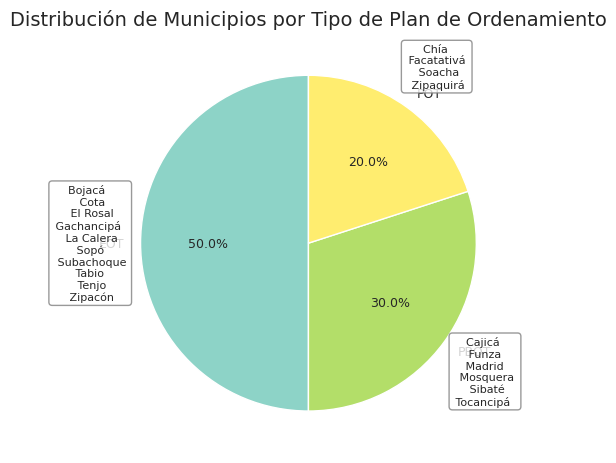

In [25]:
pot_counts = df_num['IND 2.1 TIPO'].value_counts()
pot_municipios = df_num.groupby('IND 2.1 TIPO')['MUNICIPIO'].apply(lambda x: ', '.join(sorted(x.unique()))).to_dict()

fig, ax = plt.subplots()
colors = plt.cm.Set3(np.linspace(0, 1, len(pot_counts)))

wedges, texts, __ = ax.pie(
    pot_counts, 
    labels=pot_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 9}
)

for i, wedge in enumerate(wedges):
    label = pot_counts.index[i]
    angle = (wedge.theta2 - wedge.theta1)/2. + wedge.theta1
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    
    ax.annotate(
        pot_municipios[label].replace(',', '\n'),
        xy=(x, y),
        xytext=(1.3*x, 1.3*y),
        # arrowprops=dict(arrowstyle='->', color='gray', lw=0.2),
        fontsize=8,
        ha='center',
        va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8)
    )

ax.set_title('Distribución de Municipios por Tipo de Plan de Ordenamiento', fontsize=14)
plt.tight_layout()
plt.show()


## 2. Análisis exploratorio inicial

- Conteo de registros por subregión
- Estadísticas descriptivas de indicadores de suelo y sociales

In [26]:
print('Subregion counts:')
print(df_num['SUBREGIÓN'].value_counts().to_string())

Subregion counts:
SUBREGIÓN
Sabana Centro          6
Sabana suroccidente    5
Sabana noroccidente    3
Sabana Norte           3
Soacha - Sibaté        2
Guavio                 1


In [27]:
print('Basic stats for soil indexes:')
df_num[soil_cols].describe().round(4)

Basic stats for soil indexes:


,WEI,TCMA_URBANO,Porc_poblacion_en_urbana,Densidad_urbana
count,20.0000,20.0000,20.0000,20.0000
mean,0.1634,4.7767,69.2965,11111.9717
std,0.0225,2.7268,23.4352,8042.9725
min,0.1205,1.7158,27.0500,2249.0386
25%,0.1501,3.0551,48.1150,6699.9222
50%,0.1671,4.3332,70.7000,8527.0031
75%,0.1803,5.1284,89.1550,15107.9803
max,0.2074,14.5890,99.3500,36980.6653


In [28]:
print('Basic stats for social indexes:')
df_num[social_cols].describe().round(4)

Basic stats for social indexes:


,Ingresos_tributarios_percap,Percepcion_corrupcion,Percepcion_verde,Porc_pobreza_monetaria,Porc_pobreza_extrema,Porc_pobreza_multi,GINI,Porc_informal,Porc_deficit_vivienda_cuali,Porc_deficit_vivienda_cuanti,Porc_contaminacion_aire,Porc_contaminacion_agua
count,2.000000e+01,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000
mean,1.003776e+06,30.9480,14.6710,18.8645,5.9530,5.8225,0.4361,38.7135,13.8395,1.4865,12.5095,4.0890
std,8.866163e+05,10.6633,8.6201,6.7065,2.6956,2.4580,0.0589,9.1156,4.3480,0.8575,8.9659,5.5827
min,1.743680e+05,10.7800,1.3100,10.9300,2.0700,2.9200,0.3292,26.0500,6.6900,0.2500,3.0300,0.0000
25%,5.322522e+05,25.8300,7.8350,13.2350,3.8625,4.5975,0.3982,31.9675,10.5650,0.6650,6.0650,1.2975
50%,6.238215e+05,33.5450,13.9400,16.2050,5.4050,5.3600,0.4245,38.8900,12.8050,1.4100,9.8550,2.0650
75%,1.162719e+06,35.7300,19.1075,24.3600,8.2650,6.9750,0.4868,44.3825,16.9025,2.1550,14.4650,4.0475
max,3.400603e+06,55.9800,34.3400,32.7000,10.4800,13.1700,0.5302,59.3900,24.5200,3.3700,34.6200,24.3000


In [29]:
print('Basic stats for gestion indexes:')
df_num[gestion_cols].describe().round(4)

Basic stats for gestion indexes:


,Ind_POT,Ind_eficiencia_recaudo
count,20.0000,20.0000
mean,0.8250,53.9405
std,0.2308,8.0123
min,0.5000,41.4500
25%,0.5000,47.0100
50%,1.0000,53.1250
75%,1.0000,59.9800
max,1.0000,69.6700


## 3. Relaciones suelo–social

- Matriz de dispersión suelo vs social con tendencia OLS y $R^2$ por subregión
- Correlaciones globales (Pearson)
- Correlaciones significativas tras corrección FDR

In [30]:
colors = [
    "#0072B2",  # Blue
    "#E69F00",  # Orange
    "#009E73",  # Green
    "#D55E00",  # Vermillion
    "#CC79A7",  # Purple
    "#56B4E9",  # Sky Blue
]
subregion_map = dict(zip(df_num["SUBREGIÓN"].unique(), colors))

n_social = len(social_cols)

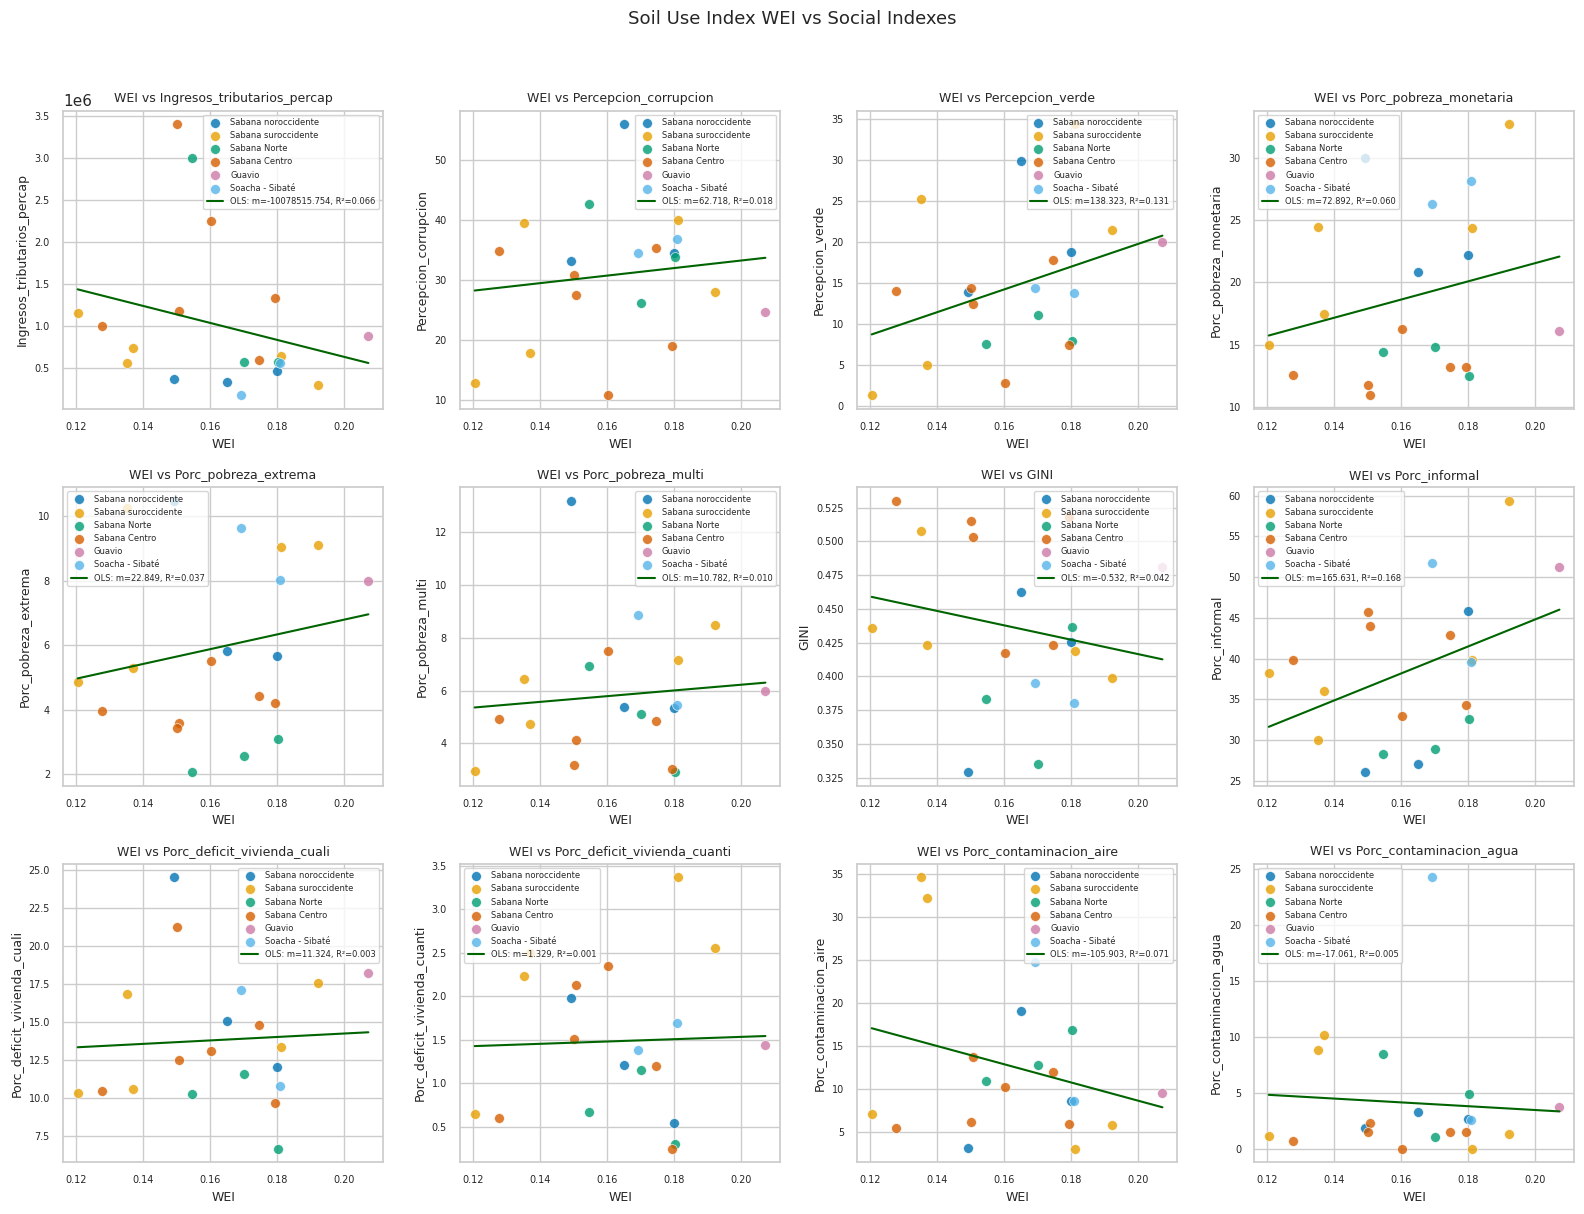

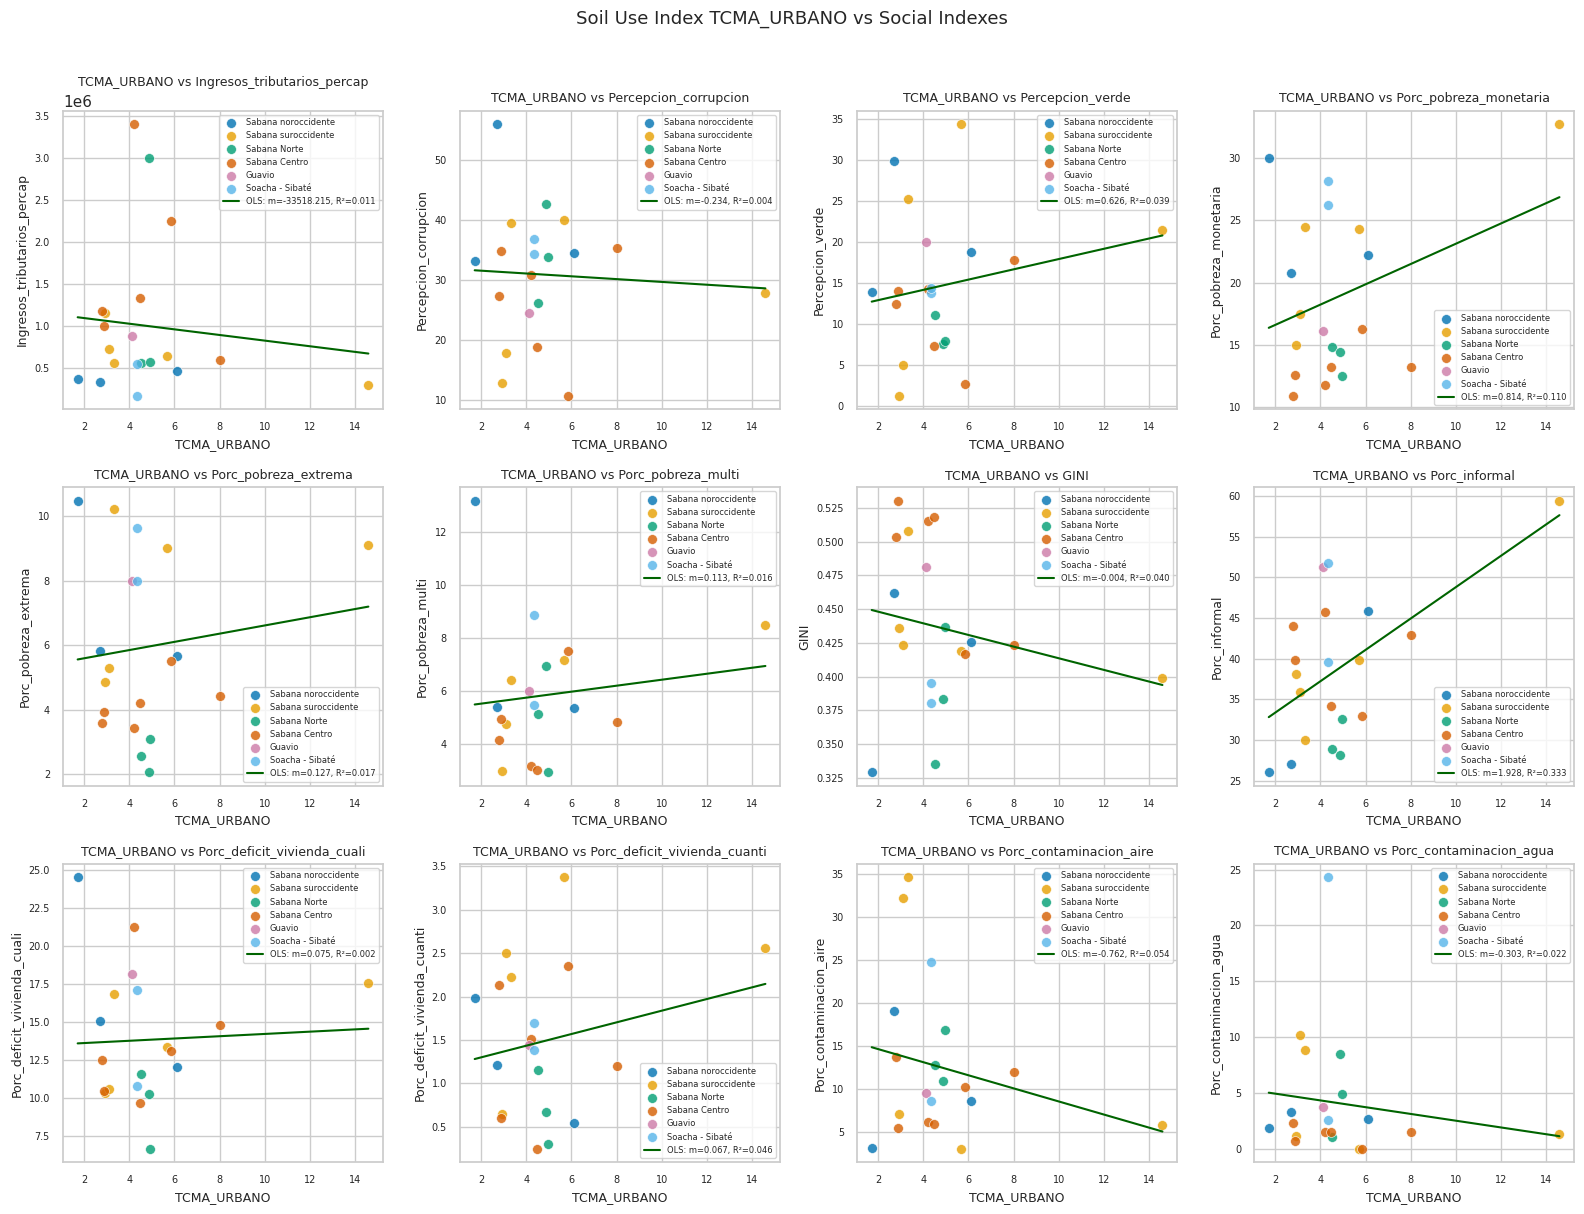

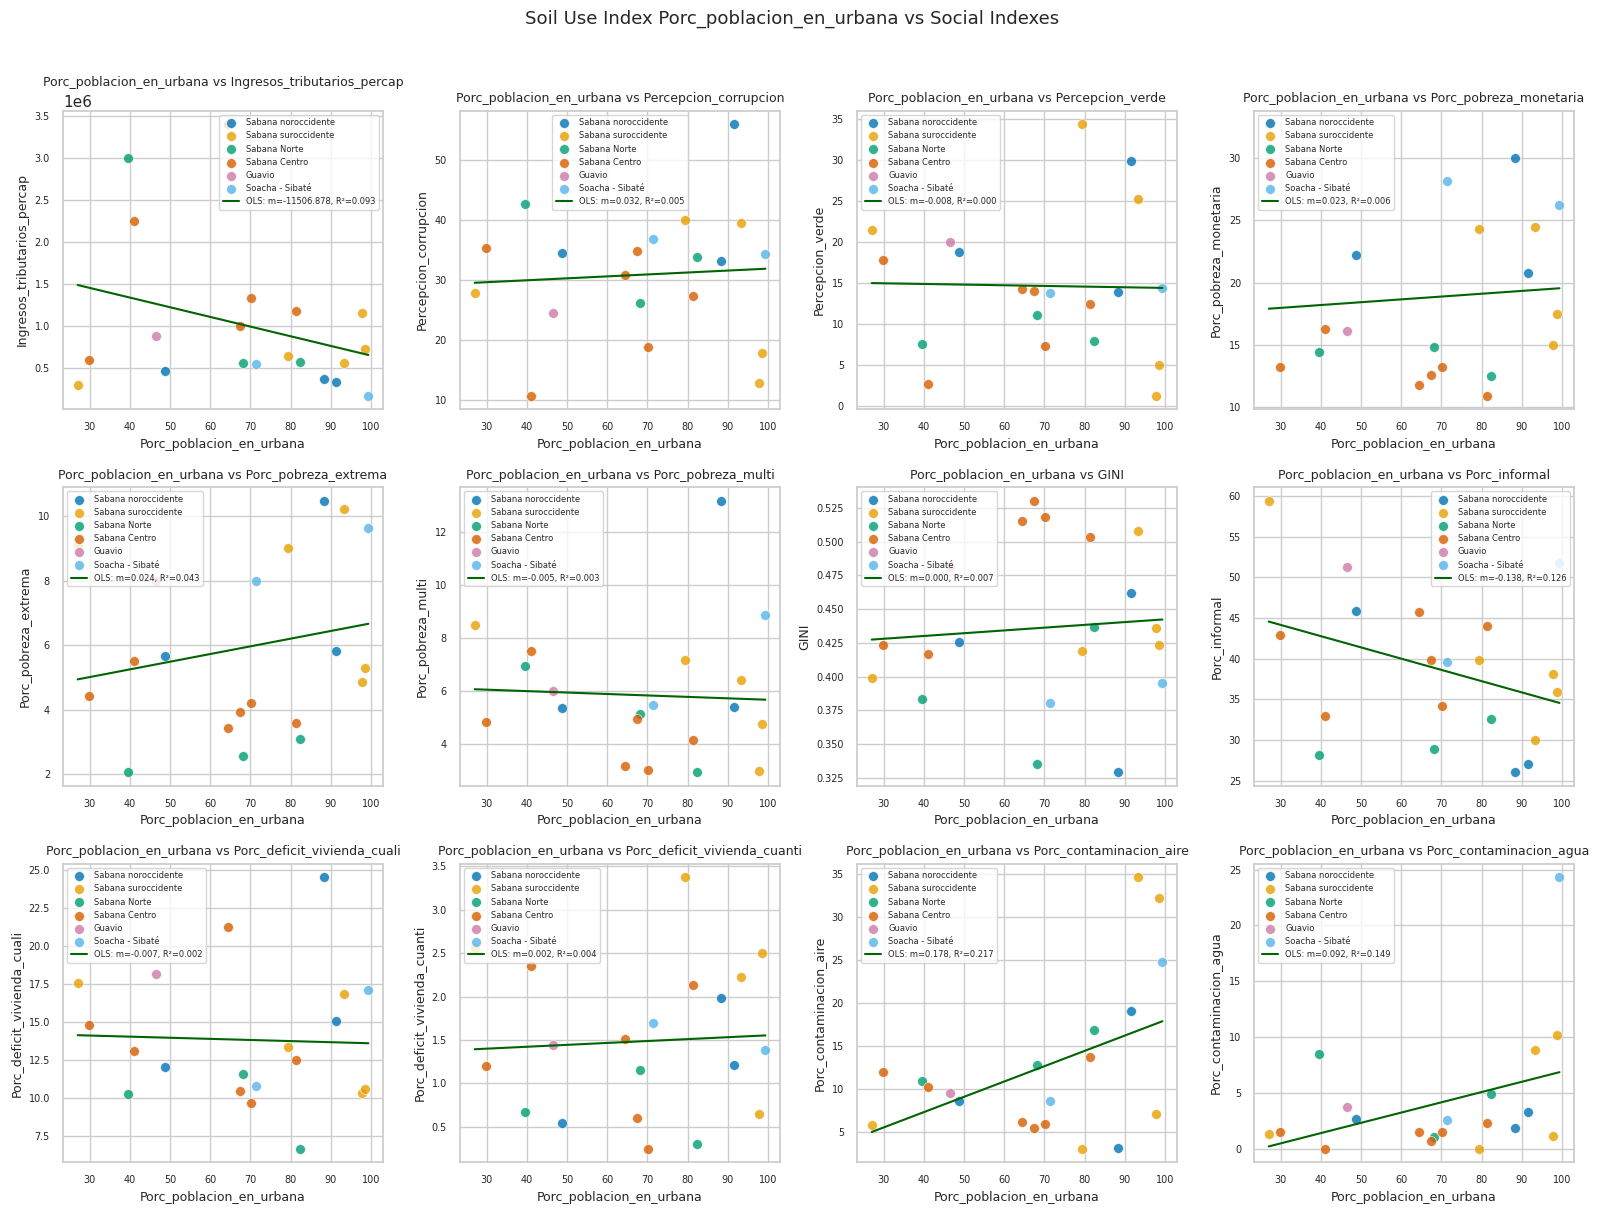

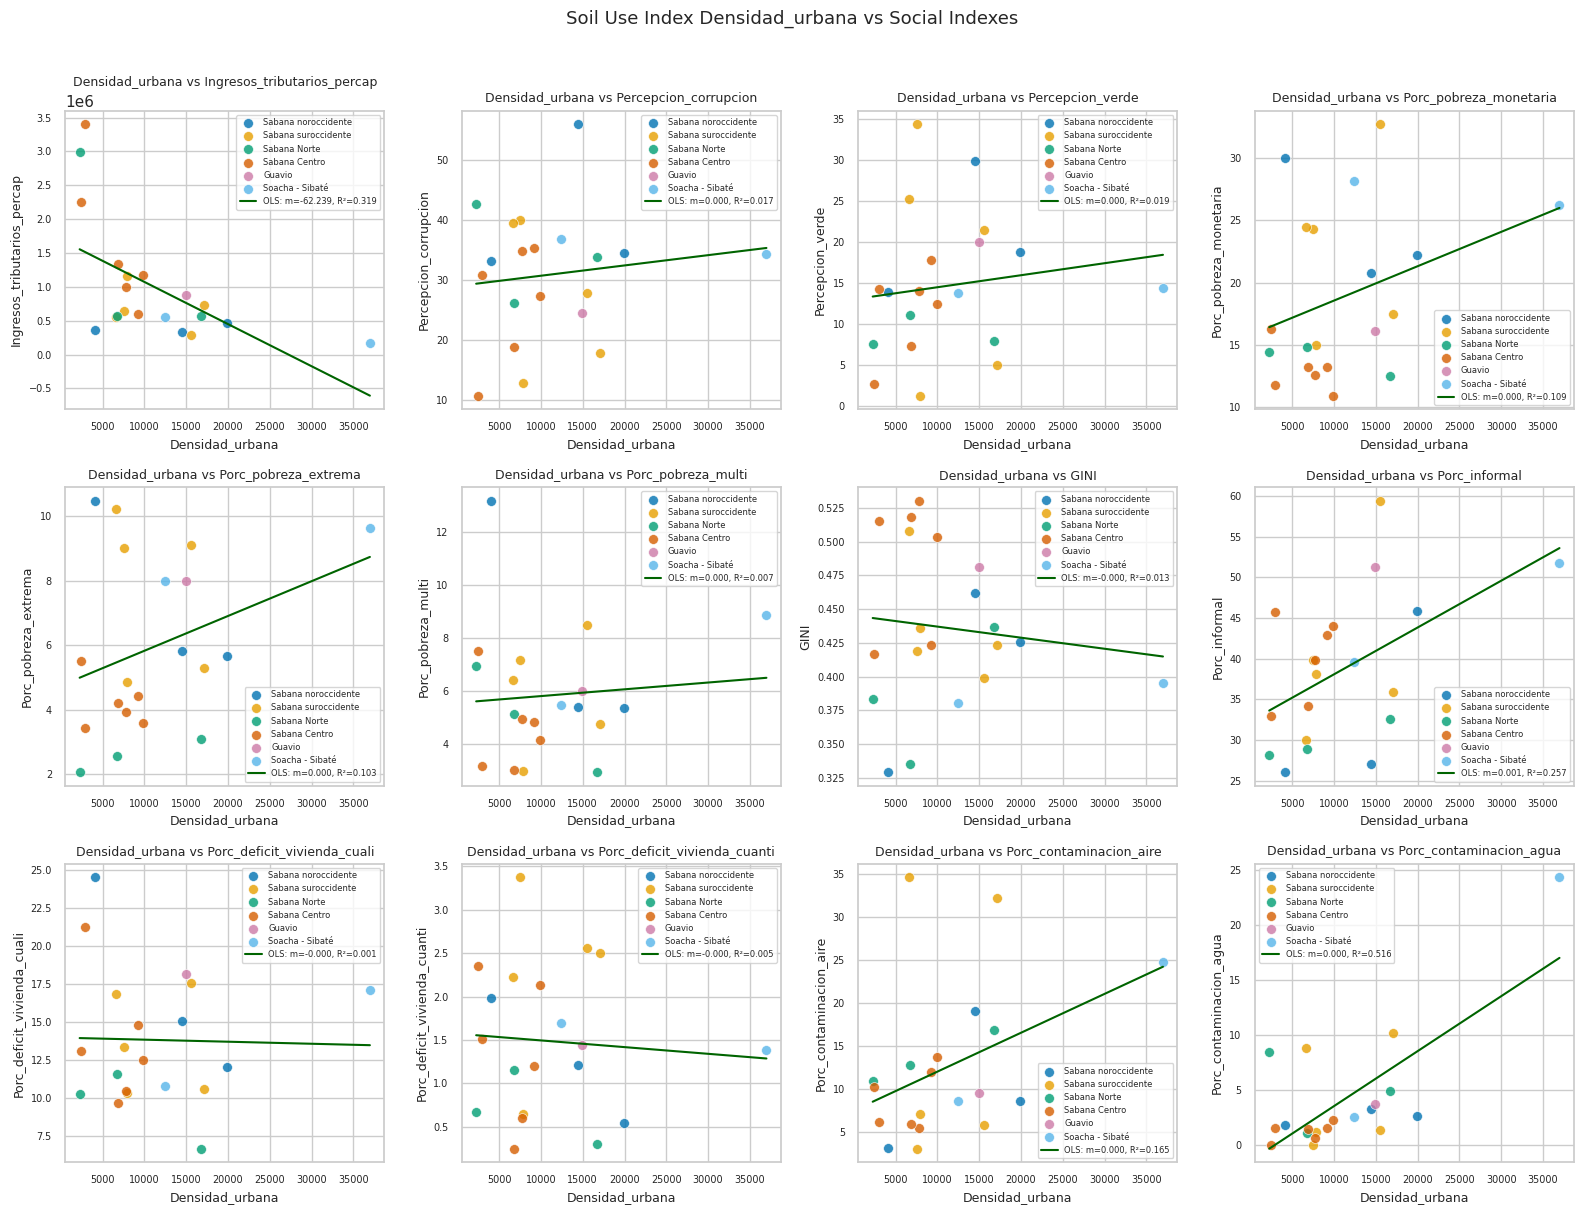

In [31]:
for soil_col in soil_cols:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12), squeeze=False)
    axes = axes.flatten()
    
    for j, social_col in enumerate(social_cols):
        ax = axes[j]
        for subreg in df_num["SUBREGIÓN"].unique():
            mask = df_num["SUBREGIÓN"] == subreg
            ax.scatter(df_num.loc[mask, soil_col], df_num.loc[mask, social_col],
                       label=subreg, color=subregion_map[subreg], alpha=0.8, s=50, edgecolors="white", linewidth=0.5)
        ax.set_xlabel(soil_col, fontsize=9)
        ax.set_ylabel(social_col, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_title(f"{soil_col} vs {social_col}", fontsize=9)
        
        # OLS trend line with R²
        sub = df_num[[soil_col, social_col]].dropna()
        valid = sub.replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) > 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(valid[soil_col], valid[social_col])
            x_line = np.linspace(valid[soil_col].min(), valid[soil_col].max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color="darkgreen", linestyle="-", linewidth=1.5,
                    label=f"OLS: m={slope:.3f}, R²={r_value**2:.3f}")
        ax.legend(fontsize=6, loc="best")
    
    # Hide unused subplots
    for j in range(n_social, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f"Soil Use Index {soil_col} vs Social Indexes", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

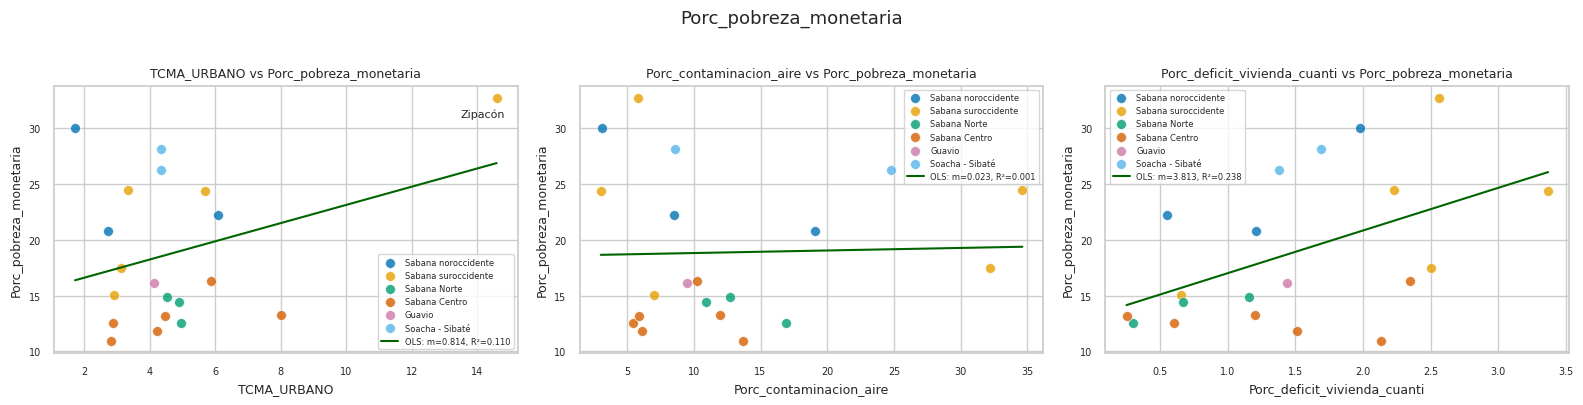

In [79]:
models_cols = ['TCMA_URBANO', 'Porc_contaminacion_aire', 'Porc_deficit_vivienda_cuanti'] #'Ind_POT', 
poverty_col = 'Porc_pobreza_monetaria'

fig, axes = plt.subplots(1, 3, figsize=(16, 4), squeeze=False)
axes = axes.flatten()

for j, model_col in enumerate(models_cols):
    ax = axes[j]
    for subreg in df_num["SUBREGIÓN"].unique():
        mask = df_num["SUBREGIÓN"] == subreg
        ax.scatter(df_num.loc[mask, model_col], df_num.loc[mask, poverty_col],
                    label=subreg, color=subregion_map[subreg], alpha=0.8, s=50, edgecolors="white", linewidth=0.5)
    ax.set_xlabel(model_col, fontsize=9)
    ax.set_ylabel(poverty_col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_title(f"{model_col} vs {poverty_col}", fontsize=9)

    if model_col == 'TCMA_URBANO':
        ax.annotate('Zipacón', 
                xy=(14, 30),               # Point to annotate
                xytext=(13.5, 31),       # Text position
                fontsize=8,
                )
    
    # OLS trend line with R²
    sub = df_num[[model_col, poverty_col]].dropna()
    valid = sub.replace([np.inf, -np.inf], np.nan).dropna()
    if len(valid) > 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(valid[model_col], valid[poverty_col])
        x_line = np.linspace(valid[model_col].min(), valid[model_col].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color="darkgreen", linestyle="-", linewidth=1.5,
                label=f"OLS: m={slope:.3f}, R²={r_value**2:.3f}")
    ax.legend(fontsize=6, loc="best")

# Hide unused subplots
for j in range(n_social, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"{poverty_col}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

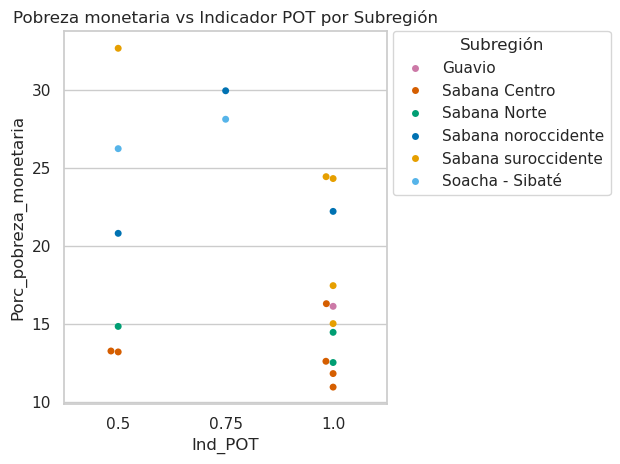

In [70]:
subregions = sorted(df_num["SUBREGIÓN"].unique())

ax = sns.swarmplot(
    data=df_num,
    x="Ind_POT",
    y="Porc_pobreza_monetaria",
    hue="SUBREGIÓN",
    hue_order=subregions,
    palette=subregion_map,
)

ax.legend(
    title="Subregión",
    bbox_to_anchor=(1.02, 1),
    # loc="upper left",
    borderaxespad=0,
)

ax.set_title(
    "Pobreza monetaria vs Indicador POT por Subregión",
    # fontsize=16,
    # fontweight="bold",
    # pad=15
)

plt.tight_layout()
plt.show()

## 3.1. Relaciones suelo–social (color = Plan Ordenamiento)

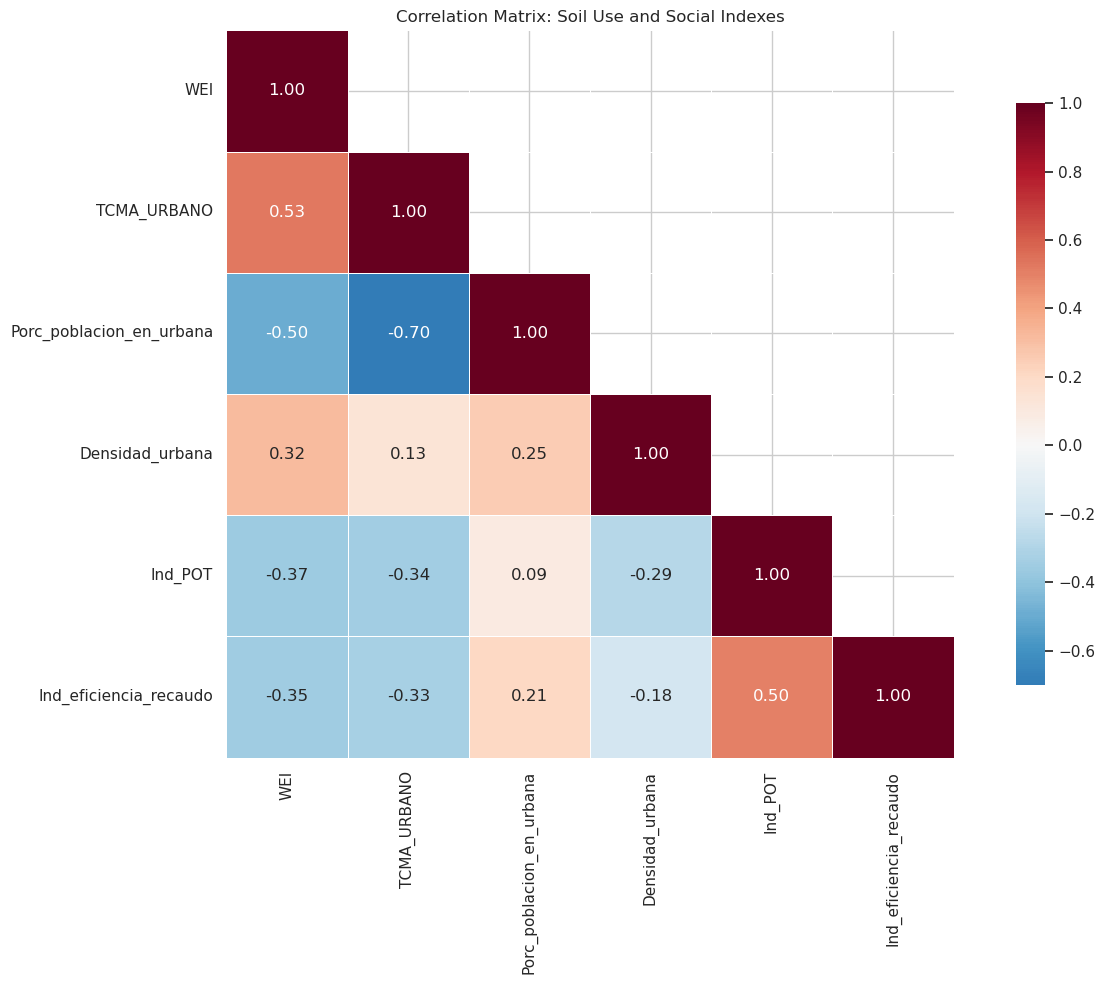

In [71]:
corr_cols = soil_cols + gestion_cols
corr_matrix = df_num[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: Soil Use and Social Indexes', fontsize=12)
plt.tight_layout()
plt.show()

In [72]:
df_num.groupby('IND 2.1 TIPO').agg({soil_col: ['count', 'mean', 'median', 'std'] for soil_col in soil_cols})

WEI                              TCMA_URBANO            \
             count      mean   median       std       count      mean   
IND 2.1 TIPO                                                            
EOT             10  0.174570  0.17705  0.018075          10  5.929080   
PBOT             6  0.142717  0.13610  0.021986           6  3.574267   
POT              4  0.166400  0.16710  0.012232           4  3.699550   

                                Porc_poblacion_en_urbana                     \
               median       std                    count       mean  median   
IND 2.1 TIPO                                                                  
EOT           5.10780  3.456109                       10  56.347000  56.520   
PBOT          3.22245  0.835080                        6  77.981667  82.305   
POT           3.56740  1.108425                        4  88.642500  86.895   

                        Densidad_urbana                              \
                    std           count          mean        median   
IND 2.1 TIPO                                                          
EOT           20.823380              10   9014.872246   7183.938875   
PBOT          23.203987               6   9004.796447   7803.459093   
POT            8.440566               4  19515.483055  15597.721830   

                            
                       std  
IND 2.1 TIPO                
EOT            5903.006042  
PBOT           5123.371699  
POT           11988.179300

In [73]:
colors = [
    "#0072B2",  # Blue
    "#E69F00",  # Orange
    "#009E73",  # Green
    "#D55E00",  # Vermillion
    "#CC79A7",  # Purple
    "#56B4E9",  # Sky Blue
]
pot_map = dict(zip(df_num["IND 2.1 TIPO"].unique(), colors))

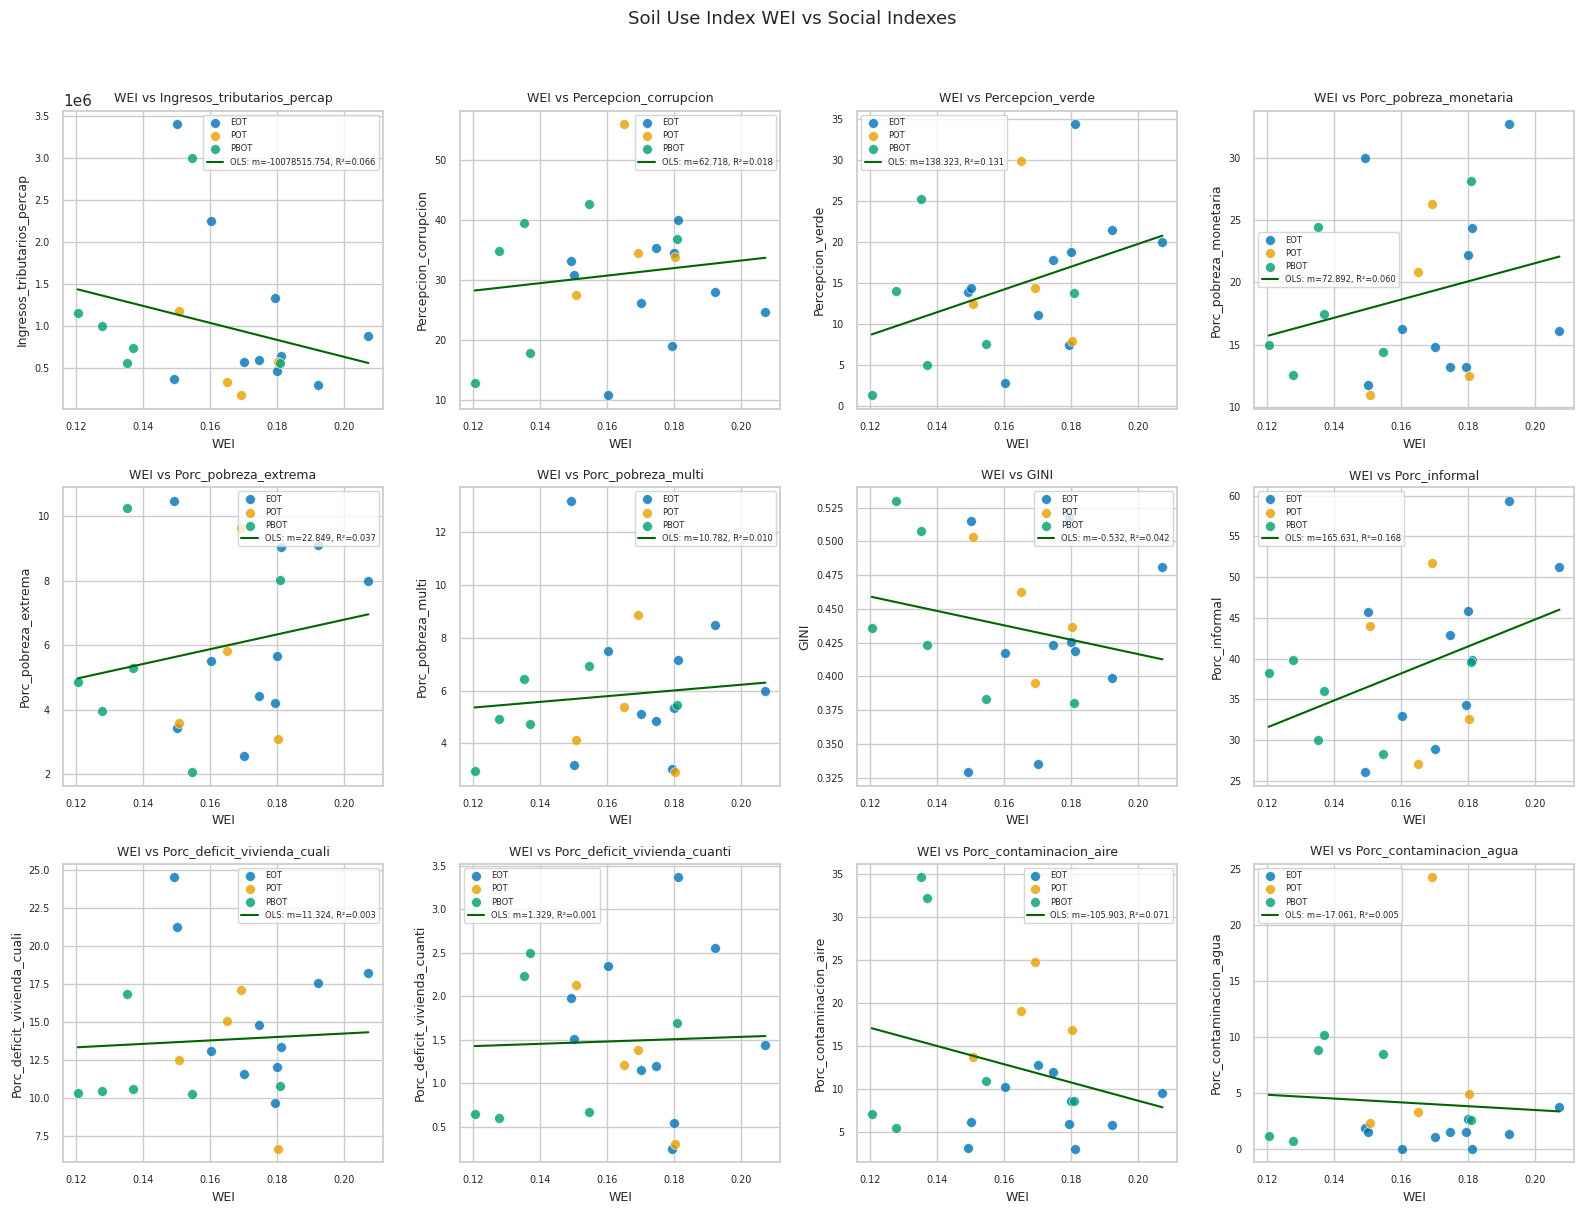

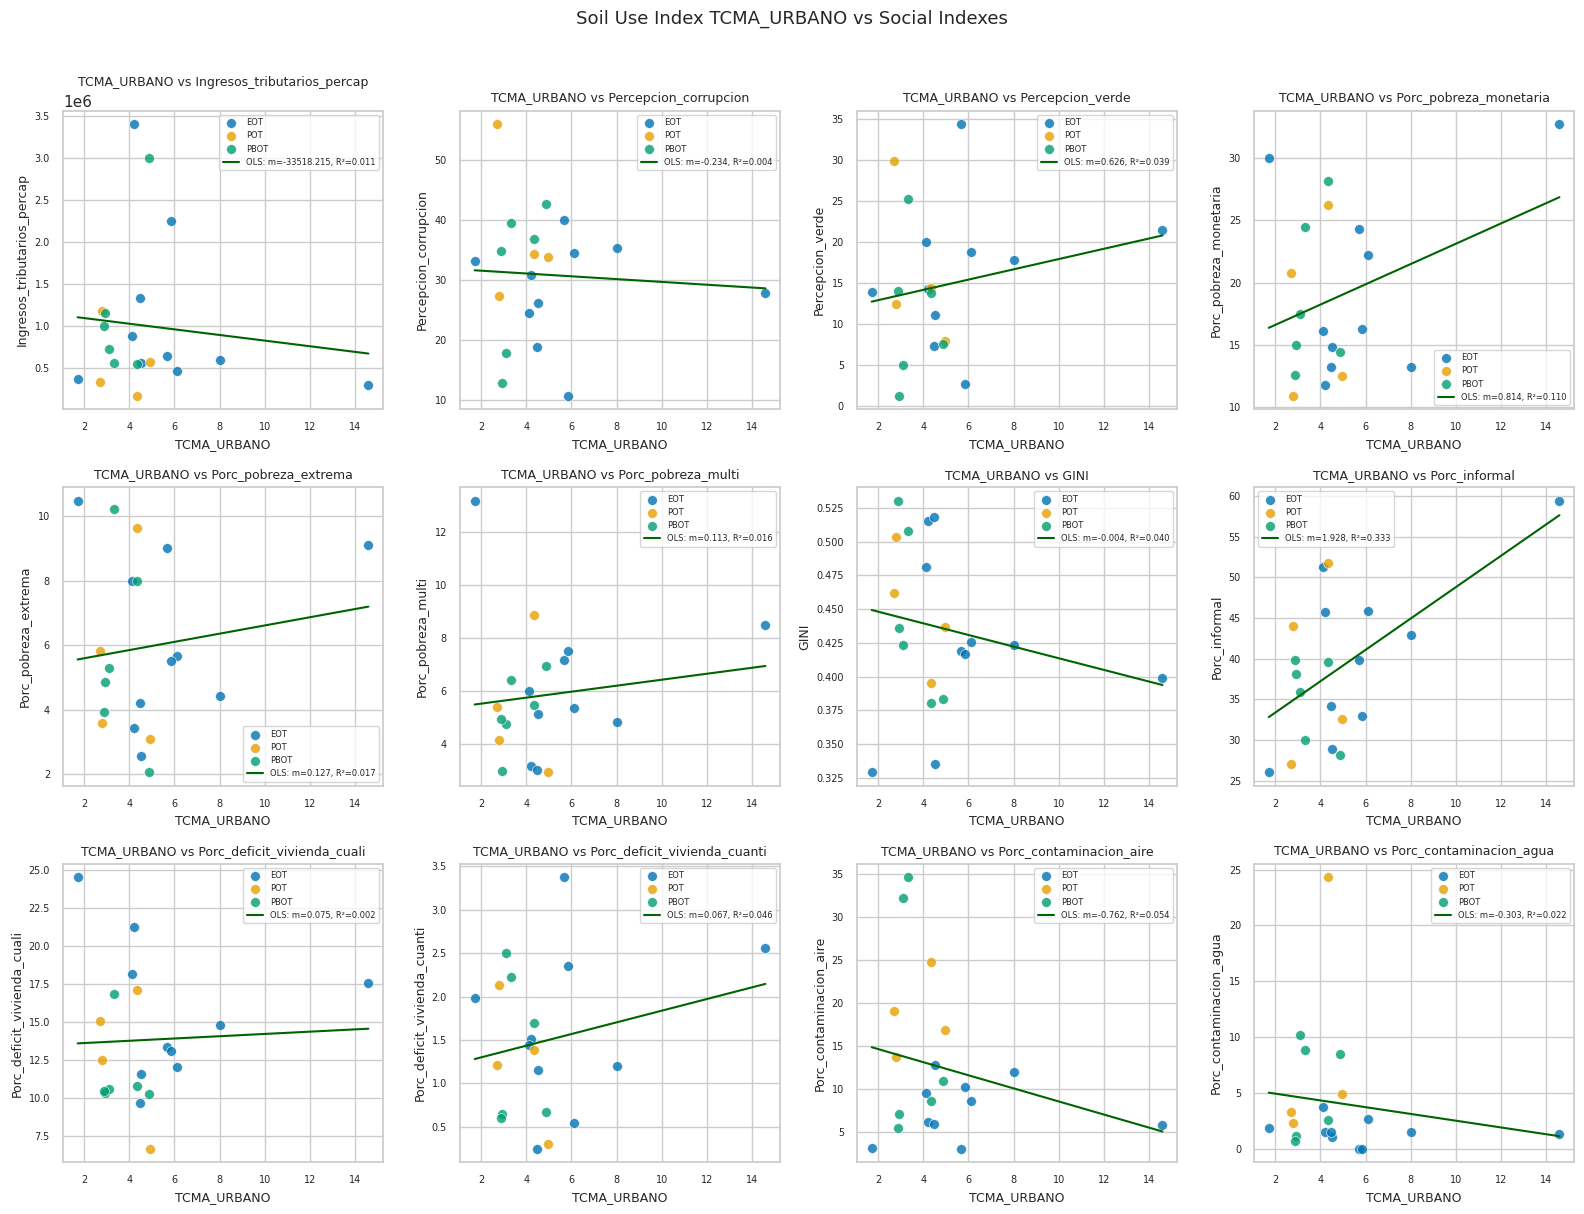

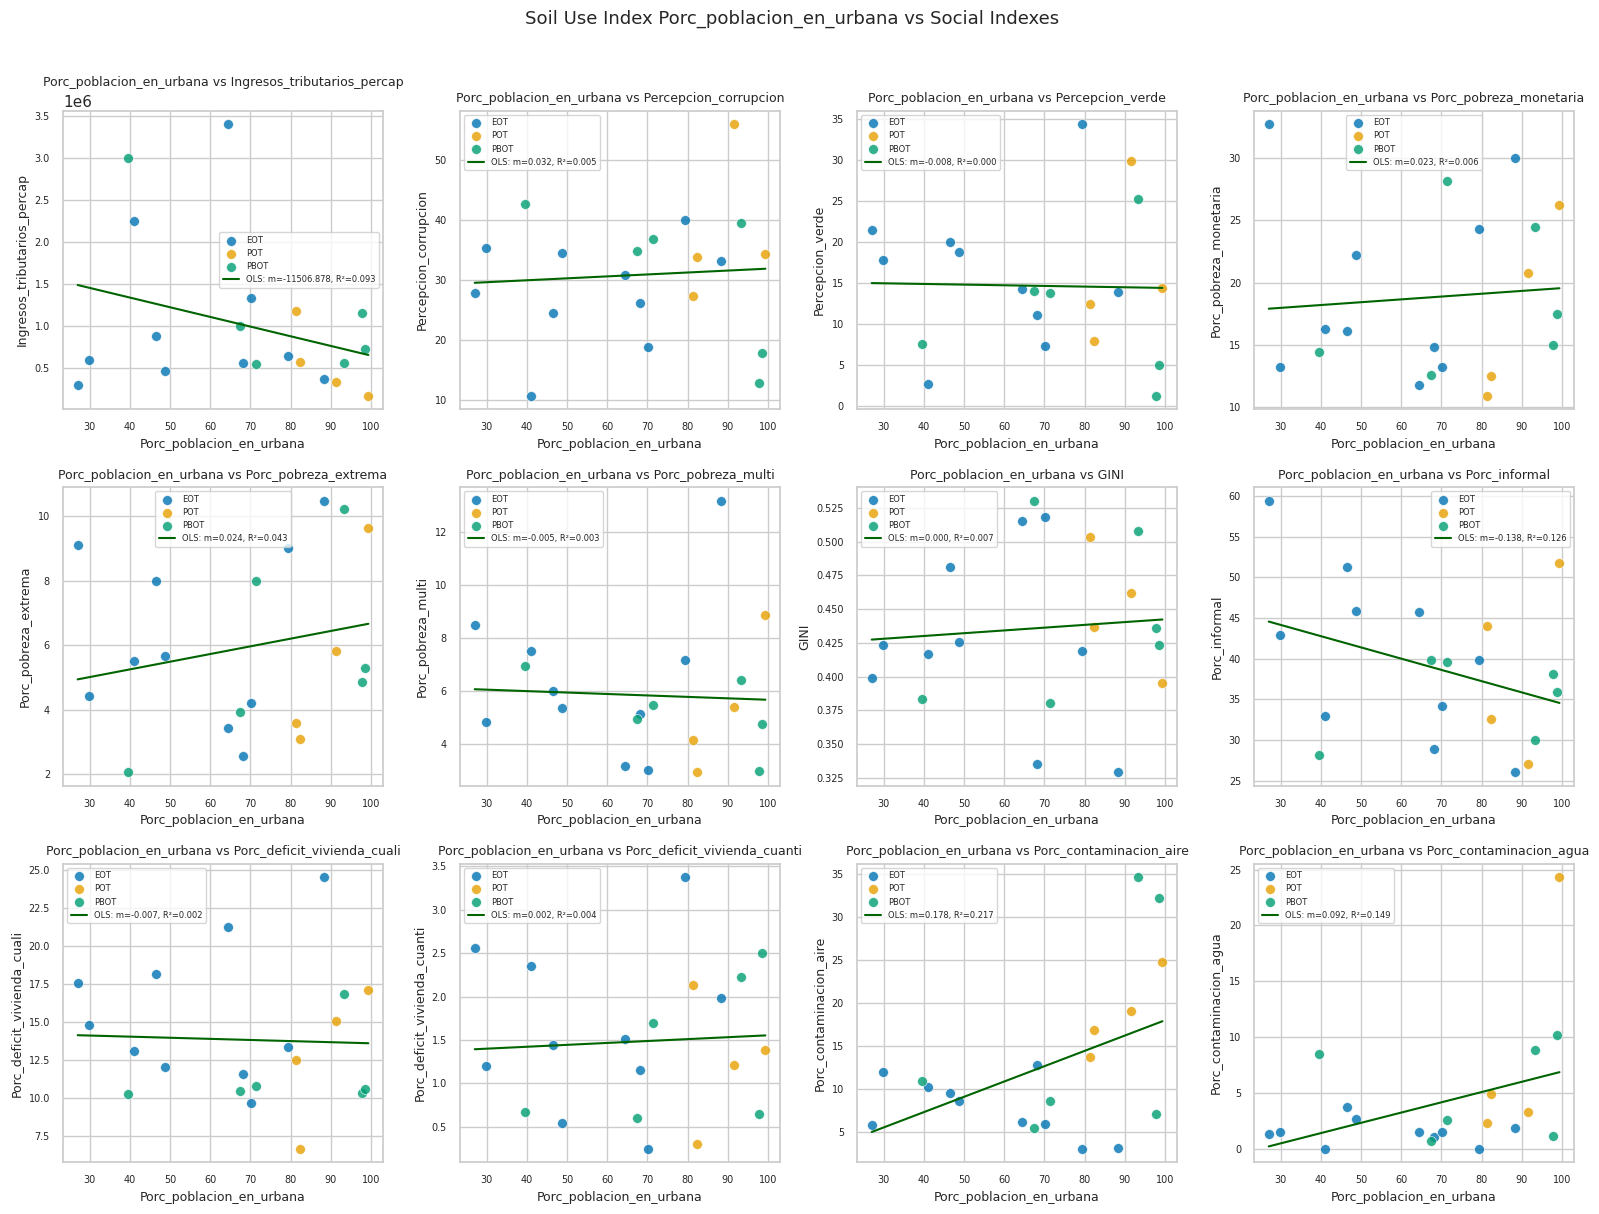

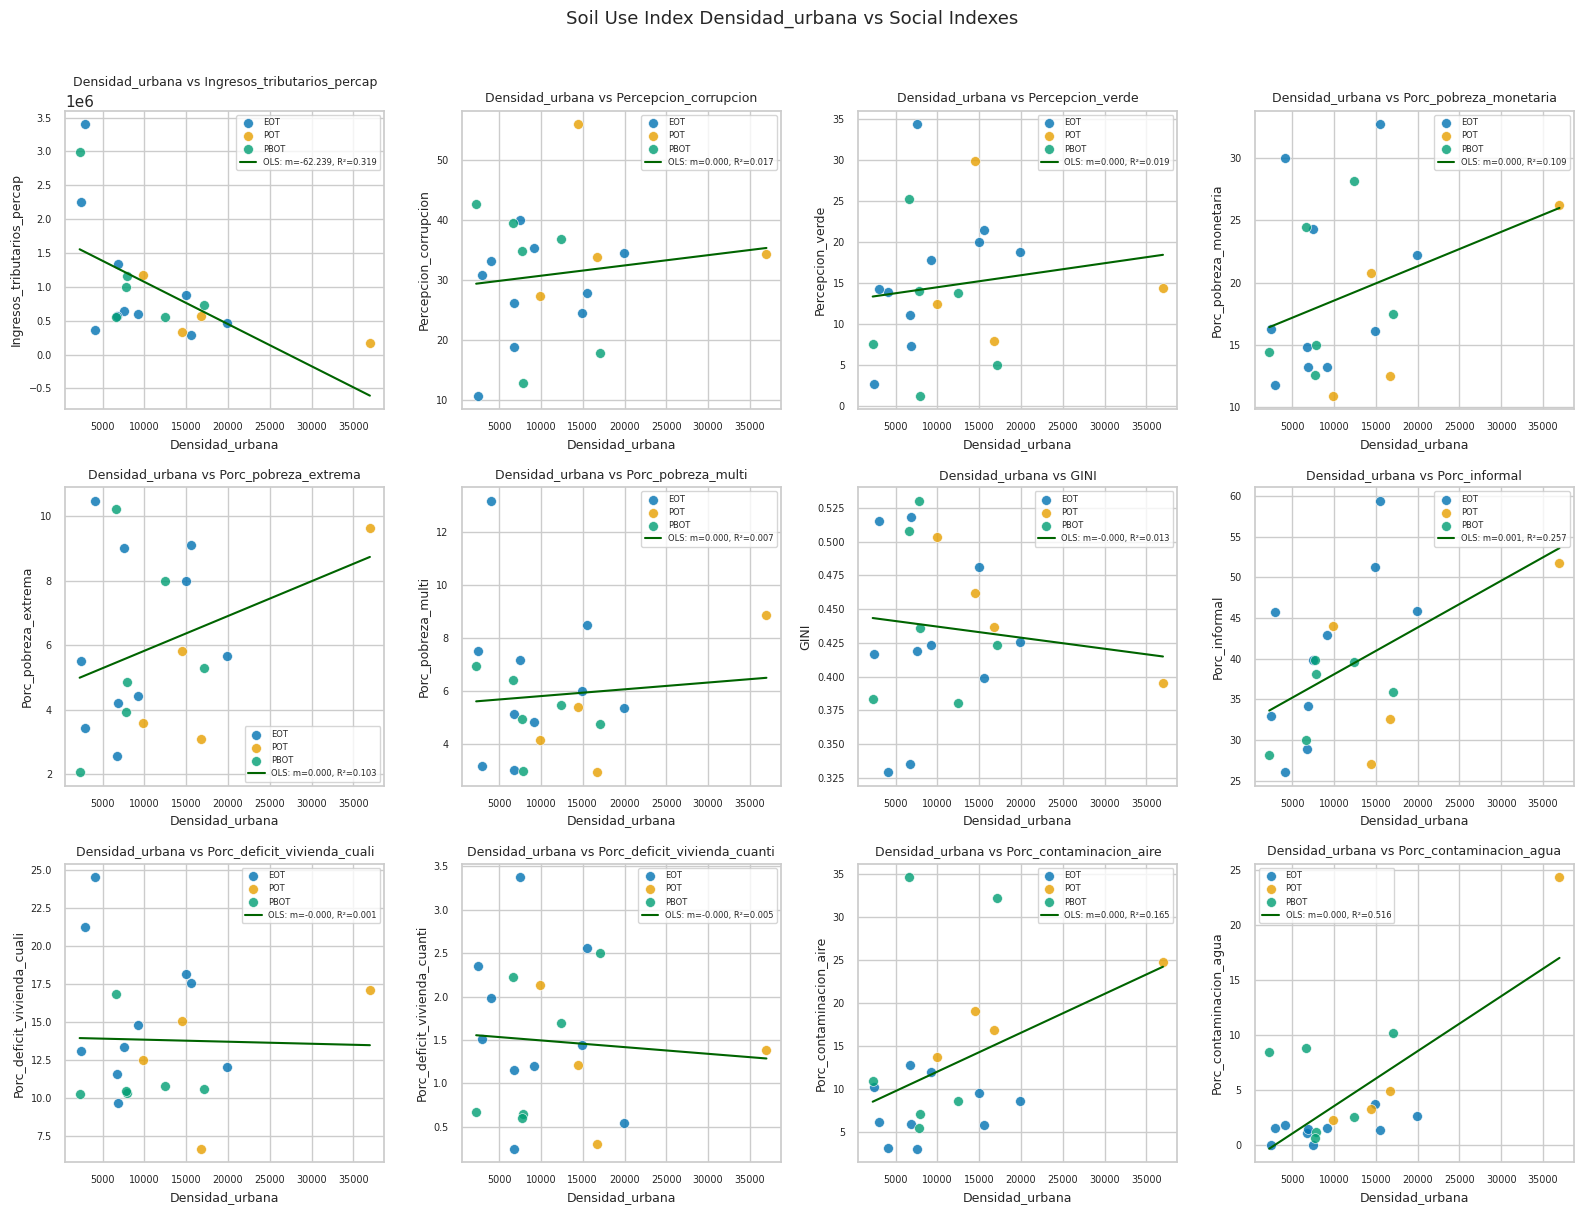

In [74]:
for soil_col in soil_cols:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12), squeeze=False)
    axes = axes.flatten()
    
    for j, social_col in enumerate(social_cols):
        ax = axes[j]
        for subreg in df_num["IND 2.1 TIPO"].unique():
            mask = df_num["IND 2.1 TIPO"] == subreg
            ax.scatter(df_num.loc[mask, soil_col], df_num.loc[mask, social_col],
                       label=subreg, color=pot_map[subreg], alpha=0.8, s=50, edgecolors="white", linewidth=0.5)
        ax.set_xlabel(soil_col, fontsize=9)
        ax.set_ylabel(social_col, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_title(f"{soil_col} vs {social_col}", fontsize=9)
        
        # OLS trend line with R²
        sub = df_num[[soil_col, social_col]].dropna()
        valid = sub.replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) > 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(valid[soil_col], valid[social_col])
            x_line = np.linspace(valid[soil_col].min(), valid[soil_col].max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color="darkgreen", linestyle="-", linewidth=1.5,
                    label=f"OLS: m={slope:.3f}, R²={r_value**2:.3f}")
        ax.legend(fontsize=6, loc="best")
    
    # Hide unused subplots
    for j in range(n_social, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f"Soil Use Index {soil_col} vs Social Indexes", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 4. Análisis de componentes principales (PCA)

- PCA por grupos: suelo y social
- Comparación de la primera componente (PC1) entre dominios

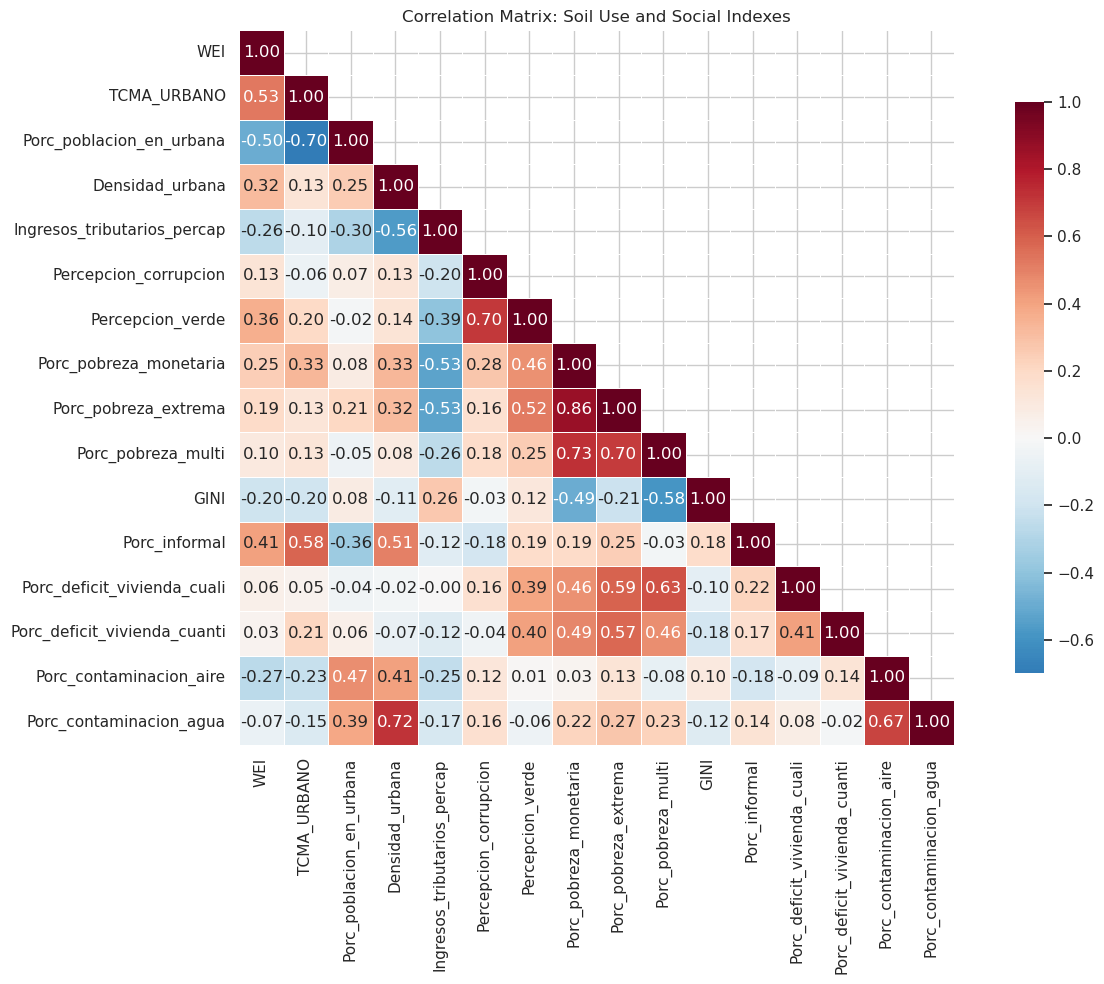

In [75]:
corr_cols = soil_cols + social_cols
corr_matrix = df_num[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: Soil Use and Social Indexes', fontsize=12)
plt.tight_layout()
plt.show()

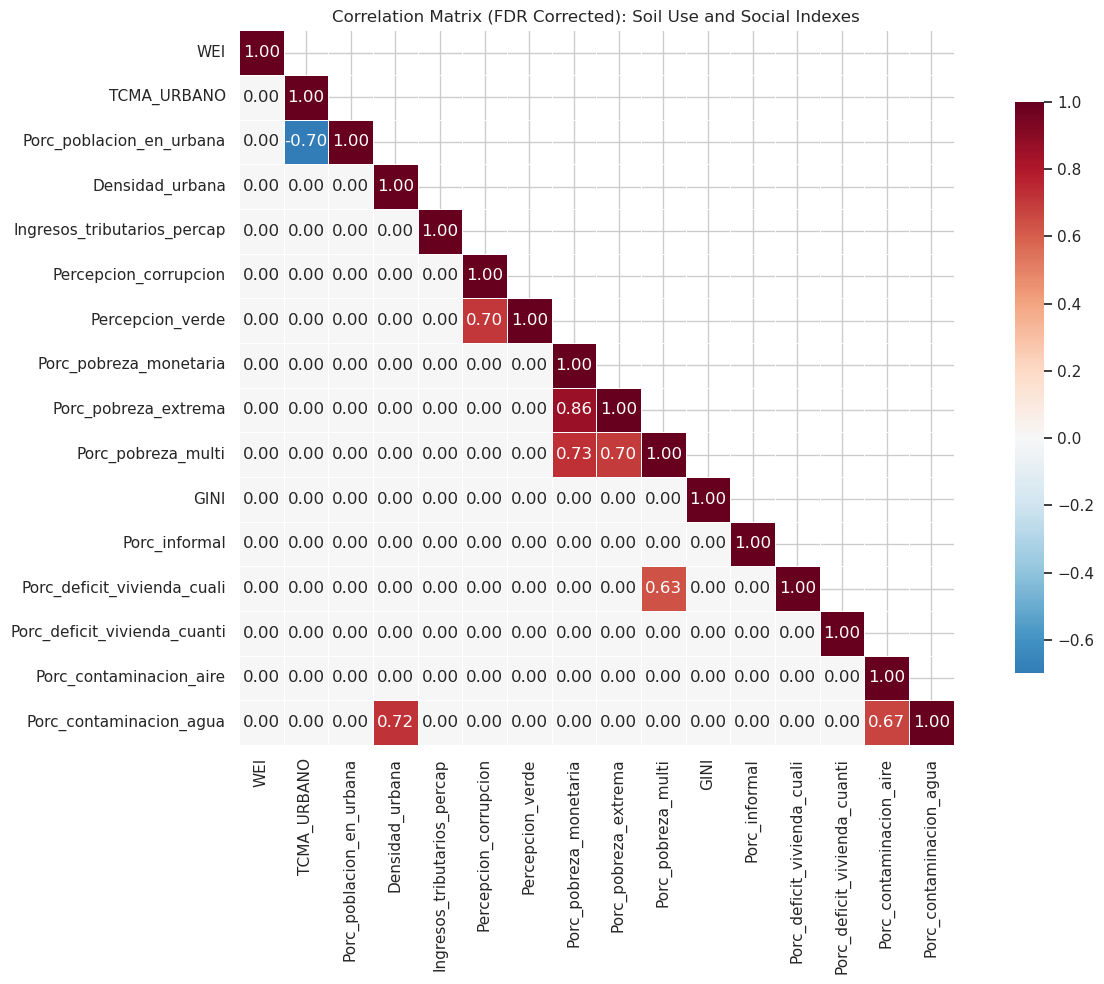

In [76]:
corr_cols = soil_cols + social_cols
corr_matrix = df_num[corr_cols].replace([np.inf, -np.inf], np.nan).corr(method="pearson")

# Calculate P-Value Matrix
n = df_num[corr_cols].shape[0]
p_matrix = np.zeros_like(corr_matrix)
for i in range(df_num[corr_cols].shape[1]):
    for j in range(df_num[corr_cols].shape[1]):
        if i != j:
            r, p = stats.pearsonr(df_num[corr_cols].iloc[:, i], df_num[corr_cols].iloc[:, j])
            p_matrix[i, j] = p

# Apply FDR Correction
p_values = p_matrix[np.triu_indices_from(p_matrix, k=1)]
reject, p_corrected = fdrcorrection(p_values, alpha=0.05)

# Assign corrected p-values back to the upper triangle
p_matrix[np.triu_indices_from(p_matrix, k=1)] = p_corrected
# Mirror to lower triangle for a full matrix
p_matrix = p_matrix + p_matrix.T - np.diag(np.diag(p_matrix))

# Create Significant Matrix (keep only FDR-significant correlations)
significant_matrix = corr_matrix.where(p_matrix < 0.05, other=0)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(significant_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix (FDR Corrected): Soil Use and Social Indexes", fontsize=12)
plt.tight_layout()
plt.show()


Soil PCA - Explained variance ratio (first 3 dimensions):
[0.54089616 0.30455657 0.10902603]
Soil PCA - Total variance captured by PC1: 0.5409 (54.09%)

Social PCA - Explained variance ratio (first 3 dimensions):
[0.3561277  0.14776849 0.13147143]
Social PCA - Total variance captured by PC1: 0.3561 (35.61%)


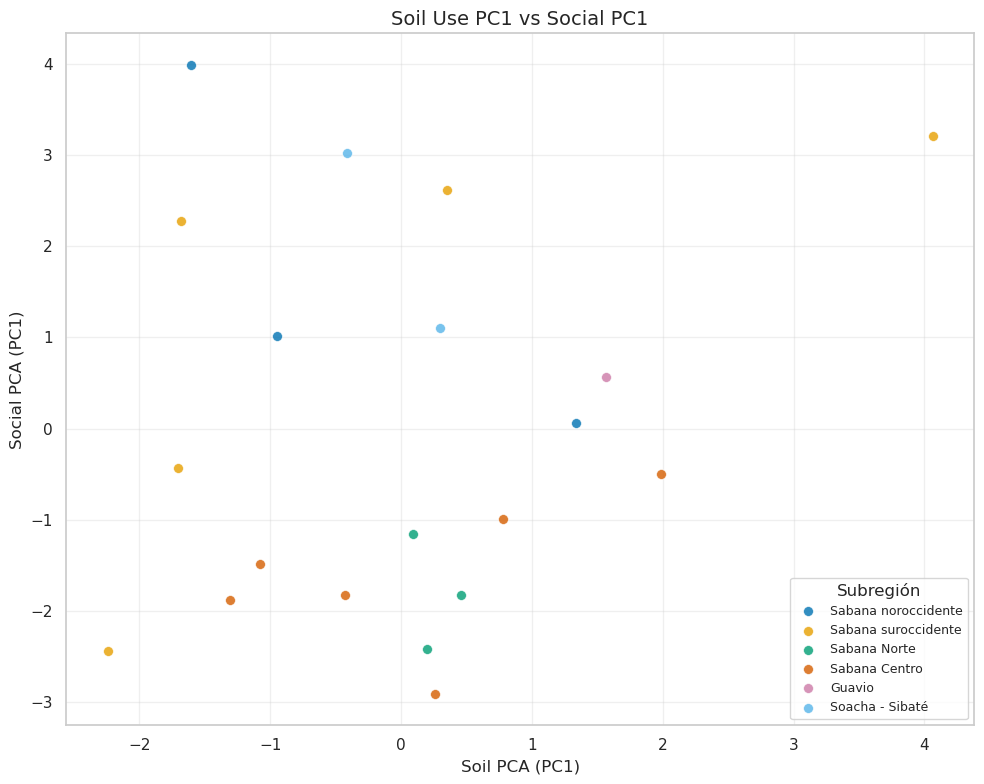

In [77]:
# Standardize data before PCA
scaler = StandardScaler()

# PCA on soil columns
soil_data = df_num[soil_cols].dropna()
soil_scaled = scaler.fit_transform(soil_data)
soil_pca = PCA()
soil_scores = soil_pca.fit_transform(soil_scaled)
soil_pca_1 = soil_scores[:, 0]

# PCA on social columns
social_data = df_num[social_cols].dropna()
social_scaled = scaler.fit_transform(social_data)
social_pca = PCA()
social_scores = social_pca.fit_transform(social_scaled)
social_pca_1 = social_scores[:, 0]

print("Soil PCA - Explained variance ratio (first 3 dimensions):")
print(soil_pca.explained_variance_ratio_[:3])
print(f"Soil PCA - Total variance captured by PC1: {soil_pca.explained_variance_ratio_[0]:.4f} ({soil_pca.explained_variance_ratio_[0]*100:.2f}%)")
print()
print("Social PCA - Explained variance ratio (first 3 dimensions):")
print(social_pca.explained_variance_ratio_[:3])
print(f"Social PCA - Total variance captured by PC1: {social_pca.explained_variance_ratio_[0]:.4f} ({social_pca.explained_variance_ratio_[0]*100:.2f}%)")

# Align indices for scatter plot
common_idx = soil_data.index.intersection(social_data.index)
soil_pca_1_aligned = soil_pca_1[common_idx.isin(soil_data.index)][common_idx.isin(soil_data.index)]
social_pca_1_aligned = social_pca_1[common_idx.isin(social_data.index)][common_idx.isin(social_data.index)]

fig, ax = plt.subplots(figsize=(10, 8))
for subreg in df_num.loc[common_idx, "SUBREGIÓN"].unique():
    mask = df_num.loc[common_idx, "SUBREGIÓN"] == subreg
    ax.scatter(soil_pca_1_aligned[mask], social_pca_1_aligned[mask],
               label=subreg, color=subregion_map[subreg], alpha=0.8, s=50, edgecolors="white", linewidth=0.5)
ax.set_xlabel("Soil PCA (PC1)", fontsize=12)
ax.set_ylabel("Social PCA (PC1)", fontsize=12)
ax.set_title("Soil Use PC1 vs Social PC1", fontsize=14)
ax.legend(title="Subregión", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
df_num.to_csv(EXPORT_DIR / 'INDICADORES_ESTUDIO_GRAL_clean.csv', index=False)
print(f'Saved cleaned data')

Saved cleaned data
